# Automatic Detection of Sleep Apneas in Children


### In this tutorial, there will be implemented three models to automatically detect apnea events: BiLSTM, ML ensemble and an hybrid approach coupling the previous ones.

In [1]:
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import os, sys
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from torch.nn.utils.rnn import pad_sequence
from datetime import datetime, timedelta
import random

notebook_dir = os.getcwd()
parent_dir = os.path.join(notebook_dir, '..')
sys.path.append(parent_dir)
from aether.rnn_bilstm import BILSTMModel
from aether.respiratory_dataset import RespiratoryDataset
from aether.utils_rnn import collate_fun, evaluate_model, find_best_threshold, calculate_metrics
from aether.utils_data import  check_apnea_criteria, compare_intervals, merge_time_intervals


### Load data and extract only the relevant features from the data features. To understand which features are relevant see the feat_selection tutorial.

In [3]:
#Execute this when you have your files with the correct data
with open('resp_events.pkl', 'rb') as f:
    resp_events = pickle.load(f)


print('N. resp events', len(resp_events))
resp_labels=np.load("resp_labels.npy") 
print('N. resp labels', len(resp_labels))
resp_feat=np.load("resp_feat.npy") 
print('N. features', len(resp_feat[0]))

# extract only feautures 0,3,7,9 (important one) 
df = pd.DataFrame(resp_feat)
idx_sel = [0, 3, 7, 9]
resp_feat_sel = df.iloc[:, idx_sel]
resp_feat  = resp_feat_sel.to_numpy()
print('N. features', len(resp_feat[0]))


N. resp events 17414
N. resp labels 10000
N. features 10
N. features 4


In [3]:
# Generate dummy data to perform simulation
n_events = 10000 
n_features = 10 

# unbalanced ratio (80% normal events (0), 20% apnea events (1))
non_apnea_ratio = 0.8
n_nonapnea = int(n_events * non_apnea_ratio)
n_apnea = n_events - n_nonapnea

print(f"Generation of {n_events} events")
print(f"Non apnea Events (Class 0): {n_nonapnea} (80%)")
print(f"Apnea Events (Class 1): {n_apnea} (20%)")

# generate labels and shuffle them
labels_non_apnea = np.zeros(n_nonapnea, dtype=int)
labels_apnea = np.ones(n_apnea, dtype=int)
resp_labels = np.concatenate([labels_non_apnea, labels_apnea])

np.random.shuffle(resp_labels)


# Generate random features for all events using a normal distribution
# to simulate real data
resp_feat = np.random.randn(n_events, n_features).astype(np.float32)

idx_sel = [0, 3, 7, 9]
resp_feat = resp_feat[:, idx_sel]
print('N. features', len(resp_feat[0]))

# Generate random respiratory events value with different length 
resp_events = []
# define an interval for the lenghts of this respiratory events
min_len = 22 
max_len = 35 

for i in range(n_events):
    length = np.random.randint(min_len, max_len + 1)
    
    # generate a temporal serie: sin + noise to simulate our normalized values
    t = np.linspace(0, 2 * np.pi, length)
    
    # for apnea events the signal should be more flat (less nopise)
    if resp_labels[i] == 1:
        signal = 0.1 * np.sin(t * 2) + 0.5 + 0.05 * np.random.randn(length)
    else:
        signal = 0.5 * np.sin(t * 3) + 1.0 + 0.1 * np.random.randn(length)

    resp_events.append(signal.astype(np.float32))


Generation of 10000 events
Non apnea Events (Class 0): 8000 (80%)
Apnea Events (Class 1): 2000 (20%)
N. features 4


## Splitting of the dataset into training, validation and testing

In [4]:
resp_combined = list(zip(resp_events, resp_feat))

X = resp_combined
y = resp_labels

original_idx_seq = np.arange(len(X))
X_train_val, X_test, y_train_val, y_test, train_idx, test_idx = train_test_split(
    X, y, original_idx_seq, test_size=0.2, random_state=42) #, stratify=y
#)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42) #, stratify=y_train_val
#)

print(f"\nTraining set shape: {len(X_train)}")
print(f"Validation set shape: {len(X_val)}")
print(f"Test set shape: {len(X_test)}\n")


Training set shape: 6000
Validation set shape: 2000
Test set shape: 2000



# BiLSTM
### Load the model and prepare the data for its training, validation and testing phases.

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bilstm_model = BILSTMModel(input_size=1).to(device)

print("\n" + "="*70)
print("BiLSTM MODEL")
print("="*70)
# Create train, validation and test datasets

#compute class weights (inverse of frequency)
class_counts = np.bincount(y_train)  #coutn occurences of each class
class_weights = 1./ class_counts
weights = class_weights[y_train]  #assign weight to each sample

train_seq = [x[0] for x in X_train]
test_seq = [x[0] for x in X_test]
val_seq = [x[0] for x in X_val]

#create a sampler using these weights (imbalances dataset)
sampler = WeightedRandomSampler(weights, num_samples=len(y_train), replacement=True)

# Create Dataset objects
train_dataset = RespiratoryDataset(train_seq, y_train, augment=False)
test_dataset = RespiratoryDataset(test_seq, y_test, augment=False)
val_dataset = RespiratoryDataset(val_seq, y_val, augment=False)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, collate_fn=collate_fun, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, collate_fn=collate_fun)
val_loader = DataLoader(val_dataset, batch_size=512, collate_fn=collate_fun)

# Calculate weights for BCELoss
class_0_count = class_counts[0]
class_1_count = class_counts[1]
# The weight for the minority class is the ratio of the majority class to the minority class
pos_weight = torch.tensor([class_0_count / class_1_count]).to(device)


BiLSTM MODEL


In [6]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(bilstm_model.parameters(), lr=0.0001, weight_decay=1e-4)

### Training phase

In [7]:
num_epochs = 50
for epoch in range(num_epochs):
    bilstm_model.train()
    total_loss = 0

    for X_batch, y_batch, seq_len_batch, sorted_idx in train_loader:
        X_batch, y_batch, seq_len_batch = X_batch.to(device), y_batch.to(device), seq_len_batch #.to(device)
        optimizer.zero_grad()
        X_batch = X_batch.unsqueeze(-1)
        outputs = bilstm_model(X_batch, seq_len_batch)

        loss = criterion(outputs.squeeze().to(device), y_batch.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()/float(seq_len_batch.size(0))

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}, Learning rate: {current_lr}")

torch.save(bilstm_model.state_dict(), "bilstm_50ep.pth")

Epoch 1/50, Loss: 0.6378, Learning rate: 0.0001
Epoch 2/50, Loss: 0.5408, Learning rate: 0.0001
Epoch 3/50, Loss: 0.4633, Learning rate: 0.0001
Epoch 4/50, Loss: 0.4621, Learning rate: 0.0001
Epoch 5/50, Loss: 0.4510, Learning rate: 0.0001
Epoch 6/50, Loss: 0.2592, Learning rate: 0.0001
Epoch 7/50, Loss: 0.1360, Learning rate: 0.0001
Epoch 8/50, Loss: 0.1034, Learning rate: 0.0001
Epoch 9/50, Loss: 0.0793, Learning rate: 0.0001
Epoch 10/50, Loss: 0.0580, Learning rate: 0.0001
Epoch 11/50, Loss: 0.0424, Learning rate: 0.0001
Epoch 12/50, Loss: 0.0309, Learning rate: 0.0001
Epoch 13/50, Loss: 0.0229, Learning rate: 0.0001
Epoch 14/50, Loss: 0.0174, Learning rate: 0.0001
Epoch 15/50, Loss: 0.0132, Learning rate: 0.0001
Epoch 16/50, Loss: 0.0103, Learning rate: 0.0001
Epoch 17/50, Loss: 0.0083, Learning rate: 0.0001
Epoch 18/50, Loss: 0.0069, Learning rate: 0.0001
Epoch 19/50, Loss: 0.0059, Learning rate: 0.0001
Epoch 20/50, Loss: 0.0051, Learning rate: 0.0001
Epoch 21/50, Loss: 0.0044, Le

In [8]:
#loading the model from the previous checkpoint
state_dict = torch.load("bilstm_50ep.pth", weights_only=True)
bilstm_model.load_state_dict(state_dict)

<All keys matched successfully>

### Results Training
Evaluate the model to gain its accuracy, the predicted values, the related class probabilities and ordered labels.
N.B. The ordering of the labels is useful when you need to compare the output of this model with that of other models, such as the ML ones.

In [9]:
train_accuracy, y_pred, y_true, y_probs = evaluate_model(bilstm_model, train_loader, device)
print(f"Train Accuracy: {train_accuracy:.2f}")

Train Accuracy: 1.00


Refine predictions based on a threshold.

In [10]:
lstm_probs = np.array(y_probs)

best_thresh = find_best_threshold(np.array(y_true), lstm_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (lstm_probs >= best_thresh).astype(int)

Best threshold based on F1-score: 0.9994
Optimal threshold: 0.9994


Calculate all the key metrics to understand the model performance.


REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00      2979
       Apnea       1.00      1.00      1.00      3021

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000


--- Confusion Matrix ---
[[2979    0]
 [   0 3021]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


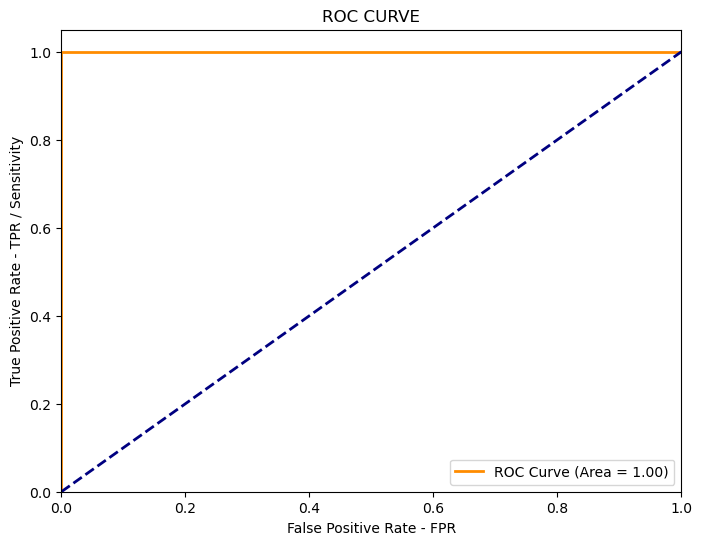

In [11]:
metrics_dict = calculate_metrics(y_true, y_pred, y_probs)

### Results Validation

Validation Accuracy: 1.00
Best threshold based on F1-score: 0.9994
Optimal threshold: 0.9994

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00      1605
       Apnea       1.00      1.00      1.00       395

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- Confusion Matrix ---
[[1605    0]
 [   0  395]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


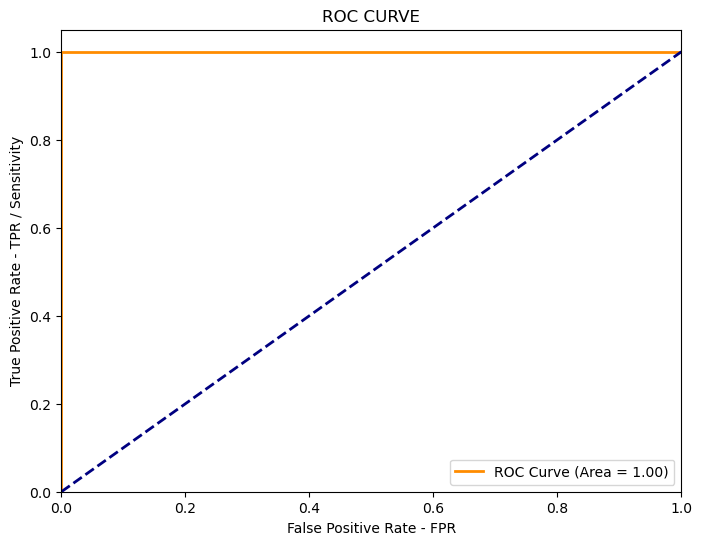

In [12]:
val_accuracy, y_pred, y_true, y_probs = evaluate_model(bilstm_model, val_loader, device)
print(f"Validation Accuracy: {val_accuracy:.2f}")

lstm_probs_val = np.array(y_probs)

best_thresh = find_best_threshold(np.array(y_true), lstm_probs_val, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (lstm_probs_val >= best_thresh).astype(int)

metrics_dict = calculate_metrics(y_true, y_pred, lstm_probs_val)


### Results Testing

Testing Accuracy: 1.00
Best threshold based on F1-score: 0.9994
Optimal threshold: 0.9994

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00      1595
       Apnea       1.00      1.00      1.00       405

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- Confusion Matrix ---
[[1595    0]
 [   0  405]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


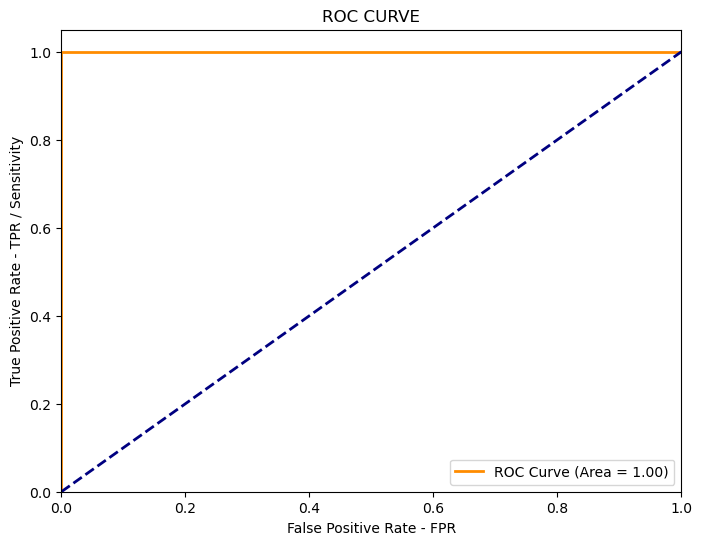

In [13]:
test_accuracy, y_pred, y_true, y_probs = evaluate_model(bilstm_model, test_loader, device)
print(f"Testing Accuracy: {test_accuracy:.2f}")

lstm_probs = np.array(y_probs)

best_thresh = find_best_threshold(np.array(y_true), lstm_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (lstm_probs >= best_thresh).astype(int)

metrics_dict = calculate_metrics(y_true, y_pred, lstm_probs)


# ML Ensemble
### Load the model and prepare the data for its training, validation and testing phases.

In [14]:
print("\n" + "="*70)
print("ML ENSEMBLE")
print("="*70)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
pos_weight = sum(y_train == 0) / sum(y_train == 1)

#Train Random Forest, XGBoost, and Logistic Regression
rf = RandomForestClassifier(class_weight=class_weight_dict, n_estimators=200, random_state=42, oob_score=True, min_samples_split=10, min_samples_leaf=1, max_features='log2', max_depth=20)
xgb = XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.01, scale_pos_weight=pos_weight, subsample=0.6, gamma=0.3, colsample_bytree=0.8)
lgr = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced', C=np.float64(0.00407559644007287))
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')

X_train_ml = [x[1] for x in X_train]
X_val_ml = [x[1] for x in X_val]
X_test_ml = [x[1] for x in X_test]


ML ENSEMBLE


### Training phase
Training of the models and successive computation of the several metrics for evaluation.

In [15]:
rf.fit(X_train_ml, y_train)
xgb.fit(X_train_ml, y_train)
lgr.fit(X_train_ml, y_train)
lda.fit(X_train_ml, y_train)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

### Results validation

In [16]:
rf_probs_val = rf.predict_proba(X_val_ml)[:, 1]
xgb_probs_val = xgb.predict_proba(X_val_ml)[:, 1]
lgr_probs_val = lgr.predict_proba(X_val_ml)[:, 1]
lda_probs_val = lda.predict_proba(X_val_ml)[:, 1]

clf = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb), ('lgr', lgr), ('lda', lda)], voting='soft')
clf.fit(X_train_ml, y_train)
final_predictions=clf.predict(X_val_ml)
ml_probs = clf.predict_proba(X_val_ml)[:,1]

In [17]:
best_thresh = find_best_threshold(y_val, ml_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (np.array(ml_probs) >= best_thresh).astype(int)

Best threshold based on F1-score: 0.2775
Optimal threshold: 0.2775



REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.01      0.02      1605
       Apnea       0.20      1.00      0.33       395

    accuracy                           0.20      2000
   macro avg       0.60      0.50      0.17      2000
weighted avg       0.84      0.20      0.08      2000


--- Confusion Matrix ---
[[  13 1592]
 [   0  395]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0081
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.1988
Accuracy: 0.2040
F1 Score: 0.3317

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4778
Precision-Recall AUC Score: 0.1902


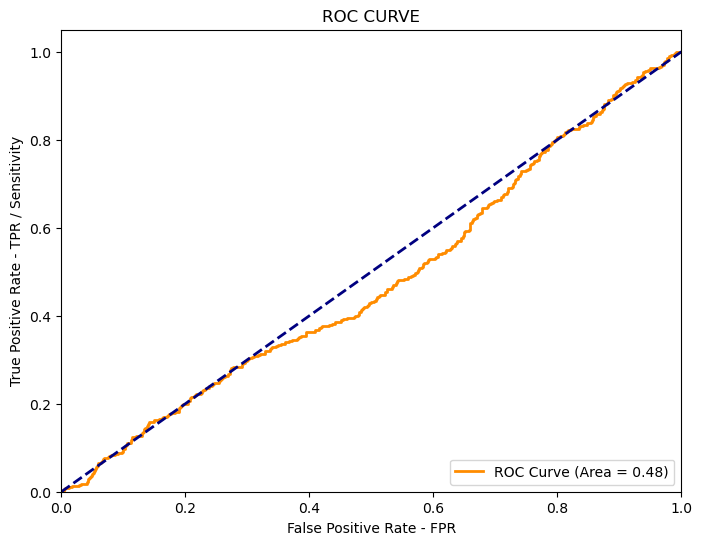

In [18]:
metrics_dict = calculate_metrics(y_val, y_pred, ml_probs)

### Results Testing

In [19]:
rf_probs = rf.predict_proba(X_test_ml)[:, 1]
xgb_probs = xgb.predict_proba(X_test_ml)[:, 1]
lgr_probs = lgr.predict_proba(X_test_ml)[:, 1]
lda_probs = lda.predict_proba(X_test_ml)[:, 1]

final_predictions=clf.predict(X_test_ml)
ml_probs = clf.predict_proba(X_test_ml)[:,1]
best_thresh = find_best_threshold(y_val, ml_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (np.array(ml_probs) >= best_thresh).astype(int)

Best threshold based on F1-score: 0.2477
Optimal threshold: 0.2477



REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.00      0.00      0.00      1595
       Apnea       0.20      1.00      0.34       405

    accuracy                           0.20      2000
   macro avg       0.10      0.50      0.17      2000
weighted avg       0.04      0.20      0.07      2000


--- Confusion Matrix ---
[[   0 1595]
 [   0  405]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0000
Negative Predictive Value (NPV): 0.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.2025
Accuracy: 0.2025
F1 Score: 0.3368

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4759
Precision-Recall AUC Score: 0.1949


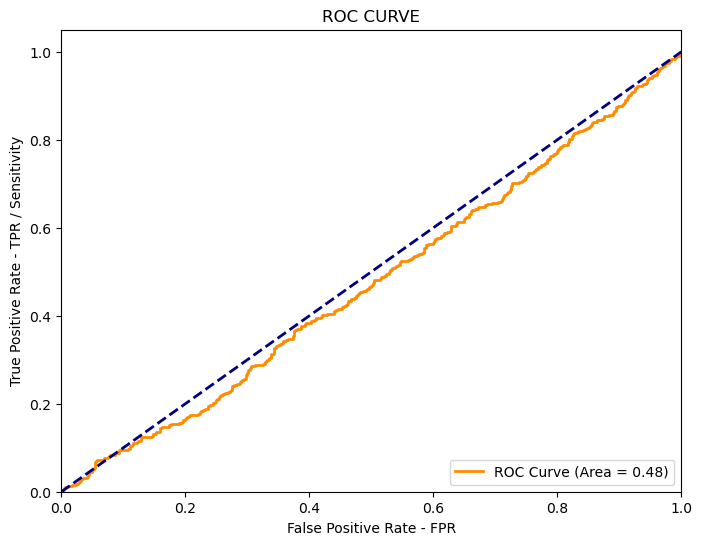

In [20]:
metrics_dict = calculate_metrics(y_test, y_pred, ml_probs)

# Hybrid model
Combine predictions of the three models to get a better prediction using information from all the models. We are combining them computing their average with equal weights.

### Results Validation

In [21]:
print("\n" + "="*70)
print("HYBRID APPROACH")
print("="*70)

bilstm_model.eval()
# Combine models testing predictions to create the meta-features.
meta_features = np.column_stack((rf_probs_val, xgb_probs_val, lgr_probs_val, lda_probs_val, lstm_probs_val))
print(f"Meta-features shape: {meta_features.shape}")


HYBRID APPROACH
Meta-features shape: (2000, 5)


In [22]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) # equal weights

# final probabilities computed as weighted average
final_weighted_probs = np.average(meta_features, axis=1, weights=weights)

best_thresh = find_best_threshold(y_val, final_weighted_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")
y_pred = (np.array(final_weighted_probs) >= best_thresh).astype(int)

Best threshold based on F1-score: 0.4219
Optimal threshold: 0.4219



REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00      1605
       Apnea       0.99      1.00      1.00       395

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- Confusion Matrix ---
[[1603    2]
 [   0  395]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9988
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.9950
Accuracy: 0.9990
F1 Score: 0.9975

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 0.9999


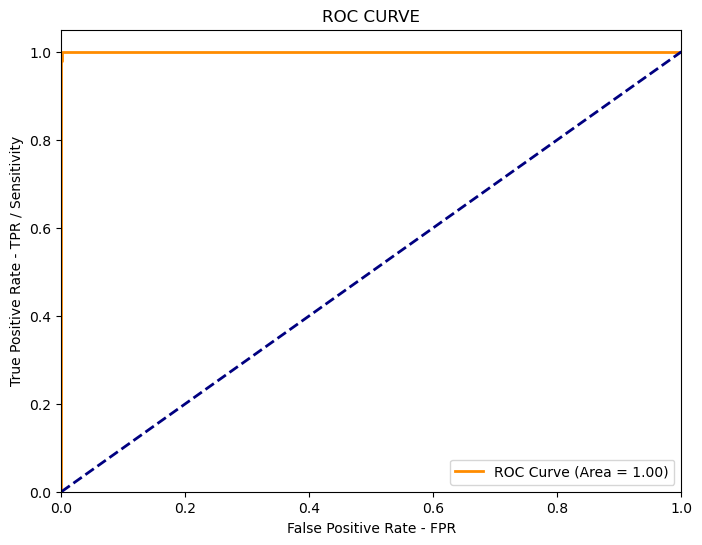

In [23]:
metrics_dict = calculate_metrics(y_val, y_pred, final_weighted_probs)

### Results Testing

In [24]:

# Combine models testing predictions to create the meta-features.
meta_features = np.column_stack((rf_probs, xgb_probs, lgr_probs, lda_probs, lstm_probs))
print(f"Meta-features shape: {meta_features.shape}")

Meta-features shape: (2000, 5)


In [25]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) # equal weights

# final probabilities computed as weighted average
final_weighted_probs = np.average(meta_features, axis=1, weights=weights)

best_thresh = find_best_threshold(y_test, final_weighted_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")
y_pred = (np.array(final_weighted_probs) >= best_thresh).astype(int)


Best threshold based on F1-score: 0.3980
Optimal threshold: 0.3980



REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00      1595
       Apnea       1.00      1.00      1.00       405

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- Confusion Matrix ---
[[1594    1]
 [   0  405]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9994
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.9975
Accuracy: 0.9995
F1 Score: 0.9988

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


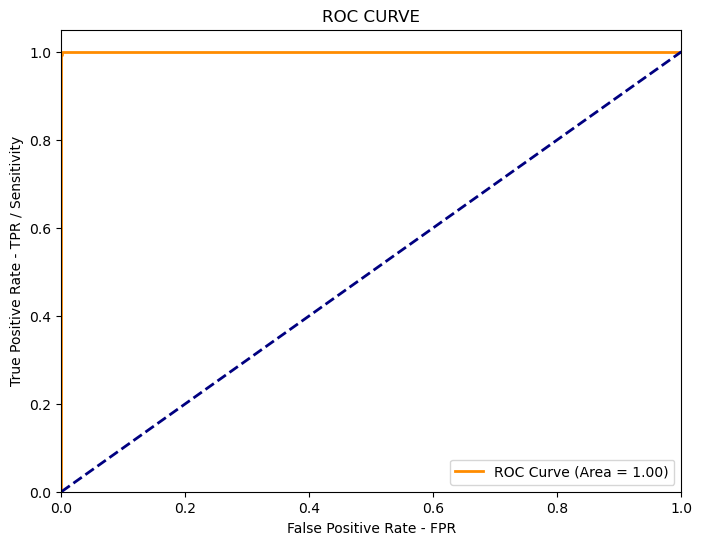

In [26]:
metrics_dict = calculate_metrics(y_test, y_pred, final_weighted_probs)

## Practical Application
Evaluation of the models on a new unseen file. After testing of the model with the new data, we have also introduced an apnea criteria based on medical knowledge on the topic to increase the accuracy of the detection.

In [29]:
# execute this cell uploading your file name
y_eval=np.load("resp_labels_eval.npy")
with open('resp_events_eval.pkl', 'rb') as f:
    X_eval = pickle.load(f)
print('N. test events', len(X_eval))

with open('time_data_eval.pkl', 'rb') as f:
    time_data = pickle.load(f)

with open('resp_int_eval.pkl', 'rb') as f:
    resp_int = pickle.load(f)

resp_feat_eval=np.load("resp_feat_eval.npy") 
print('N. features', len(resp_feat_eval[0]))

df = pd.DataFrame(resp_feat_eval) #, columns=feature_names)
idx_sel = [0, 2, 7, 9]
resp_feat_sel = df.iloc[:, idx_sel]
resp_feat_eval  = resp_feat_sel.to_numpy()
print('N. features', len(resp_feat_eval[0]))

with open('apnee_true_eval.pkl', 'rb') as f:
    apnee_true = pickle.load(f)
print('N. apnee', len(apnee_true))


N. test events 11499
N. features 10
N. features 4
N. apnee 0


In [28]:
# Generate dummy data to perform simulation

n_apnea = 10         # apnea events (Label = 1)
n_nonapnea = 40     
n_events = n_apnea + n_nonapnea
n_features = 10      
min_len = 22         
max_len = 35        

# param for non-consecutive gaps
min_gap = 10
max_gap = 100

print(f"Generation of {n_events} events")
print(f"Non apnea Events (Class 0): {n_nonapnea}")
print(f"Apnea Events (Class 1): {n_apnea}")

# generate labels and shuffle them
labels_non_apnea = np.zeros(n_nonapnea, dtype=int)
labels_apnea = np.ones(n_apnea, dtype=int)

y_eval = np.concatenate([labels_non_apnea, labels_apnea])
np.random.shuffle(y_eval)

print(f"N. Events: {n_events}")

# Generate random features for all events using a normal distribution
# to simulate real data

resp_feat_eval = np.random.randn(n_events, n_features).astype(np.float32)

# feature selection
idx_sel = [0, 3, 7, 9]
resp_feat_eval = resp_feat_eval[:, idx_sel]

print(f'\nN. features: {len(resp_feat_eval[0])}')


# Generate random respiratory events value with different length 

X_eval = []
for i in range(n_events):
    length = np.random.randint(min_len, max_len + 1)
    
    # generate a temporal serie: sin + noise to simulate our normalized values
    t = np.linspace(0, 2 * np.pi, length)
    
    # for apnea events the signal should be more flat (less noise)
    if resp_labels[i] == 1:
        signal = 0.1 * np.sin(t * 2) + 0.5 + 0.05 * np.random.randn(length)
    else:
        signal = 0.5 * np.sin(t * 3) + 1.0 + 0.1 * np.random.randn(length)

    X_eval.append(signal.astype(np.float32))


# generation of intervals of the true apneas

resp_int = []
apnee_true_events = []
current_global_index = 0
apnea_intervals_count = 0
t_format = '%H:%M:%S.%f'

for i in range(n_events):
    length = len(X_eval[i])
    label = resp_labels[i]

    start = current_global_index
    end = current_global_index + length - 1

    resp_int.append([start, end])
    # add interval only if it is labeled as 1
    if label == 1:
        apnee_true_events.append([start, end])
        apnea_intervals_count += 1
    
    current_global_index = end + 1
    
    # add the gap (to have non consecutive intervals)
    if i < n_events - 1:
        gap = random.randint(min_gap, max_gap)
        current_global_index += gap

        
total_samples = current_global_index
print(f"Total sequential samples derived: {total_samples}")
print(f"Total respiration intervals: {len(resp_int)}")

# generate the related timestamps for all the sample data

sampling_rate= 1
start_time = datetime.now()
time_data = [(start_time + timedelta(seconds=i / sampling_rate)).strftime(t_format)[:-3] for i in range(total_samples+1000)]

duration_minutes = total_samples / sampling_rate / 60
print(f"Total time duration simulated: {duration_minutes:.2f} minutes")

apnee_true = []

for start_index, end_index in apnee_true_events:

    start_time_apnea = time_data[start_index]
    end_time_apnea = time_data[end_index]
    
    apnee_true.append([start_time_apnea, end_time_apnea])

print(f"N. True apneas: {len(apnee_true)}")


Generation of 50 events
Non apnea Events (Class 0): 40
Apnea Events (Class 1): 10
N. Events: 50

N. features: 4
Total sequential samples derived: 4376
Total respiration intervals: 50
Total time duration simulated: 72.93 minutes
N. True apneas: 6


It can happen that merging files containing the ground-truth apneas some of them are repeated, so this check is added to avoid this.

In [29]:
if len(apnee_true)!=0:
    merged_intervals = merge_time_intervals(apnee_true)
    print('N. apnee', len(merged_intervals))
else:
    merged_intervals = apnee_true
    print('N. apnee', len(apnee_true))


N. apnee 6


### BiLSTM

Prepare data for BiLSTM. Need to keep into account that event sequences have different lenghts, and this must be handled before giving them into input to the BiLSTM network.

In [30]:
eval_seq = [np.array(interval) for interval in X_eval]
# Convert sequences to PyTorch tensors
eval_seq = [torch.tensor(seq, dtype=torch.float32) for seq in eval_seq]

# Get sequence lengths
seq_lengths = torch.tensor([len(seq) for seq in eval_seq])

# Pad sequences to match the longest one
padded_sequences = pad_sequence(eval_seq, batch_first=True)

# Sort sequences by descending length
seq_lengths, sorted_idx = seq_lengths.sort(descending=True)
padded_sequences = padded_sequences[sorted_idx]

seq_lengths_sorted = seq_lengths
tensor_labels = torch.tensor(y_eval, dtype=torch.long)

labels_sorted = tensor_labels[sorted_idx]

In [31]:
lstm_probs = []
y_preds = []
with torch.no_grad():  # Disable gradient computation
    padded_sequences = padded_sequences.to(device)
    padded_events = padded_sequences.unsqueeze(-1)
    print('N. test events', padded_events.size())
    # Forward pass through model
    predictions = bilstm_model(padded_events, seq_lengths_sorted)
    lstm_probs.extend(torch.sigmoid(predictions).cpu().numpy())
    preds = (torch.sigmoid(predictions).cpu().numpy() > 0.5)
    y_preds.extend(preds)


lstm_probs_np = np.concatenate(lstm_probs, axis=0)

# restore orginal order
original_idx = torch.argsort(sorted_idx).numpy()
lstm_probs = lstm_probs_np[original_idx]


N. test events torch.Size([50, 35, 1])


Best threshold based on F1-score: 0.0011
Optimal threshold: 0.0011

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.00      0.00      0.00        40
       Apnea       0.20      1.00      0.33        10

    accuracy                           0.20        50
   macro avg       0.10      0.50      0.17        50
weighted avg       0.04      0.20      0.07        50


--- Confusion Matrix ---
[[ 0 40]
 [ 0 10]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0000
Negative Predictive Value (NPV): 0.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.2000
Accuracy: 0.2000
F1 Score: 0.3333

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.3775
Precision-Recall AUC Score: 0.1711


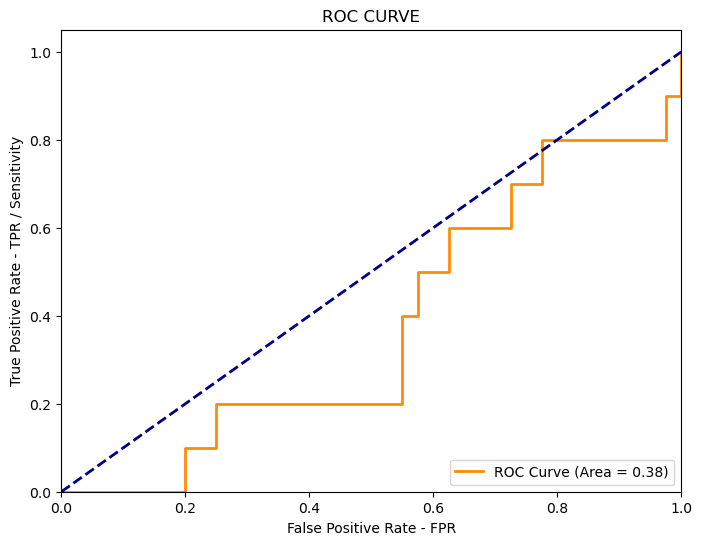

In [32]:

best_thresh = find_best_threshold(np.array(y_eval), lstm_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_preds = (lstm_probs >= best_thresh).astype(int)

metrics_dict = calculate_metrics(y_eval, y_preds, lstm_probs)


Apnea detected from segment 0 to 49, total duration: 1428 seconds

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.00      0.00      0.00        40
       Apnea       0.20      1.00      0.33        10

    accuracy                           0.20        50
   macro avg       0.10      0.50      0.17        50
weighted avg       0.04      0.20      0.07        50


--- Confusion Matrix ---
[[ 0 40]
 [ 0 10]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0000
Negative Predictive Value (NPV): 0.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.2000
Accuracy: 0.2000
F1 Score: 0.3333

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.3775
Precision-Recall AUC Score: 0.1711


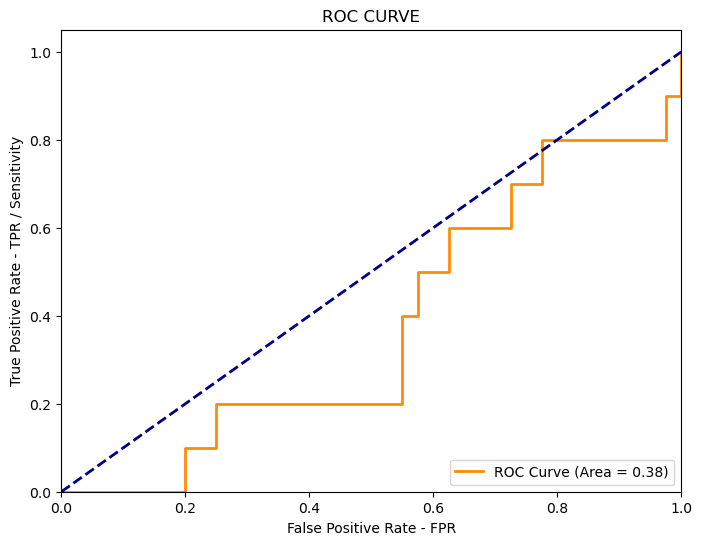

In [33]:
y_pred_apneas, apnea_events, apnea_events_time = check_apnea_criteria(X_eval, y_preds, time_data, resp_int, None)
# Print the detected apnea events
for start, end, duration in apnea_events:
    print(f"Apnea detected from segment {start} to {end}, total duration: {duration} seconds")

#apply the mask of the new apneas refined with the apnea criteria also to the probabilities 
y_pred_apneas_np = np.array(y_pred_apneas)
y_prob_np = np.array(lstm_probs)

mask = (y_pred_apneas_np == 0)
y_probs_check = y_prob_np
y_probs_check[mask] = 0

metrics_dict = calculate_metrics(y_eval, y_pred_apneas, y_probs_check)

In [34]:
print('N. apnee detected', len(apnea_events_time))

apnee_intervals = [event[:2] for event in apnea_events_time]
intersecting, unique_list1, unique_list2 = compare_intervals(merged_intervals, apnee_intervals)

print("N. Intervalli Intersecati/apnee trovate:", len(intersecting))
print("N. apnee non trovate:", len(unique_list1))
print("N. apnee trovate in più:", len(unique_list2))

N. apnee detected 1
N. Intervalli Intersecati/apnee trovate: 1
N. apnee non trovate: 5
N. apnee trovate in più: 0


### ML ensemble

In [35]:
X_test_ml = resp_feat_eval

rf_probs = rf.predict_proba(X_test_ml)[:, 1]
xgb_probs = xgb.predict_proba(X_test_ml)[:, 1]
lgr_probs = lgr.predict_proba(X_test_ml)[:, 1]
lda_probs = lda.predict_proba(X_test_ml)[:, 1]

Best threshold based on F1-score: 0.3132
Optimal threshold: 0.3132

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.05      0.10        40
       Apnea       0.21      1.00      0.34        10

    accuracy                           0.24        50
   macro avg       0.60      0.53      0.22        50
weighted avg       0.84      0.24      0.15        50


--- Confusion Matrix ---
[[ 2 38]
 [ 0 10]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0500
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.2083
Accuracy: 0.2400
F1 Score: 0.3448

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4100
Precision-Recall AUC Score: 0.1790


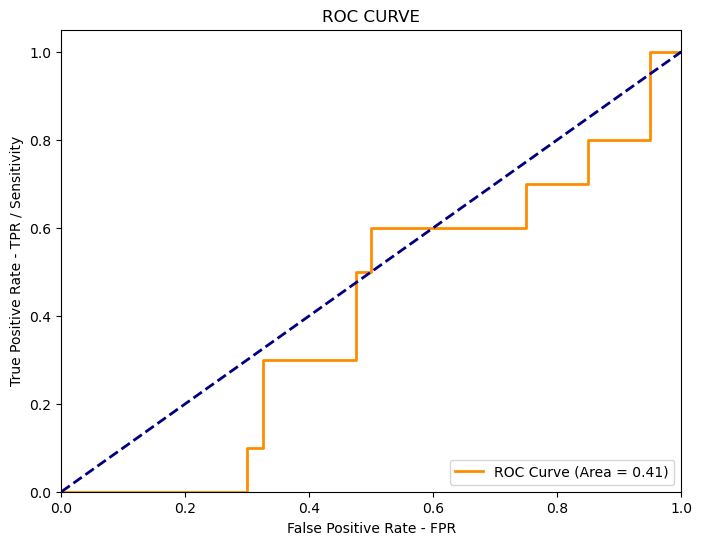

In [36]:
y_preds=clf.predict(X_test_ml)
y_proba = clf.predict_proba(X_test_ml)[:,1]

best_thresh = find_best_threshold(y_eval, y_proba, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")
y_preds = (np.array(y_proba) >= best_thresh).astype(int)
metrics_dict = calculate_metrics(y_eval, y_preds, y_proba)

Apnea detected from segment 2 to 34, total duration: 935 seconds
Apnea detected from segment 36 to 49, total duration: 405 seconds

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.07      0.14        40
       Apnea       0.21      1.00      0.35        10

    accuracy                           0.26        50
   macro avg       0.61      0.54      0.25        50
weighted avg       0.84      0.26      0.18        50


--- Confusion Matrix ---
[[ 3 37]
 [ 0 10]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0750
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.2128
Accuracy: 0.2600
F1 Score: 0.3509

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4150
Precision-Recall AUC Score: 0.1799


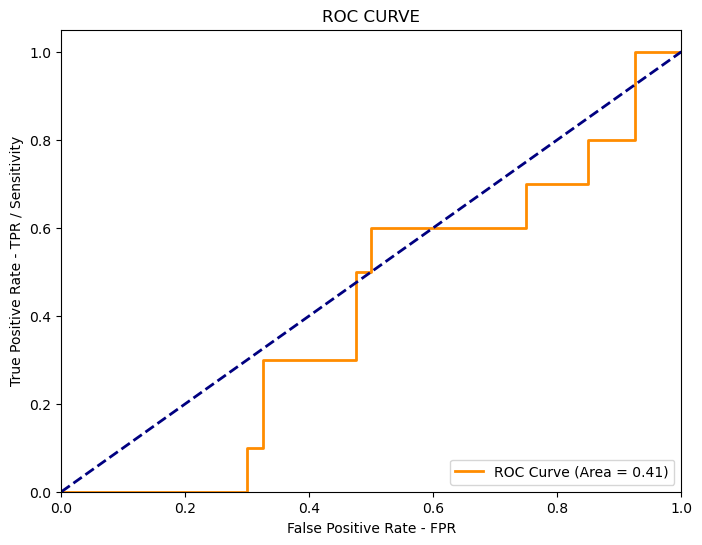

In [37]:
y_pred_apneas, apnea_events, apnea_events_time = check_apnea_criteria(X_eval, y_preds, time_data, resp_int, None)
# Print the detected apnea events
for start, end, duration in apnea_events:
    print(f"Apnea detected from segment {start} to {end}, total duration: {duration} seconds")

#apply the mask of the new apneas refined with the apnea criteria also to the probabilities 
y_pred_apneas_np = np.array(y_pred_apneas)
y_prob_np = np.array(y_proba)

mask = (y_pred_apneas_np == 0)
y_probs_check = y_prob_np
y_probs_check[mask] = 0

metrics_dict = calculate_metrics(y_eval, y_pred_apneas, y_probs_check)

In [38]:
print('N. apnee detected', len(apnea_events_time))

apnee_intervals = [event[:2] for event in apnea_events_time]
intersecting, unique_list1, unique_list2 = compare_intervals(merged_intervals, apnee_intervals)

print("N. Intervalli Intersecati/apnee trovate:", len(intersecting))
print("N. apnee non trovate:", len(unique_list1))
print("N. apnee trovate in più:", len(unique_list2))

N. apnee detected 2
N. Intervalli Intersecati/apnee trovate: 2
N. apnee non trovate: 4
N. apnee trovate in più: 0


### Hybrid Approach

In [39]:
print(f"rf_probs shape: {rf_probs.shape}")      # Output atteso: (11499, 1) o (11499,)
print(f"xgb_probs shape: {xgb_probs.shape}")    # Output atteso: (11499, 1) o (11499,)
print(f"lgr_probs shape: {lgr_probs.shape}")    # Output atteso: (11499, 1) o (11499,)
print(f"lda_probs shape: {lda_probs.shape}")    # Output atteso: (11499, 1) o (11499,)
print(f"lstm_probs shape: {lstm_probs.shape}")  # **Output problematico: (5000, 1) o (5000,)**

test_meta_features = np.column_stack((rf_probs, xgb_probs, lgr_probs, lda_probs, lstm_probs))
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
final_weighted_probs = np.average(test_meta_features, axis=1, weights=weights)

y_preds = (final_weighted_probs > 0.5).astype(int)

rf_probs shape: (50,)
xgb_probs shape: (50,)
lgr_probs shape: (50,)
lda_probs shape: (50,)
lstm_probs shape: (50,)


Best threshold based on F1-score: 0.2508
Optimal threshold: 0.2508

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.05      0.10        40
       Apnea       0.21      1.00      0.34        10

    accuracy                           0.24        50
   macro avg       0.60      0.53      0.22        50
weighted avg       0.84      0.24      0.15        50


--- Confusion Matrix ---
[[ 2 38]
 [ 0 10]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0500
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.2083
Accuracy: 0.2400
F1 Score: 0.3448

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.3425
Precision-Recall AUC Score: 0.1610


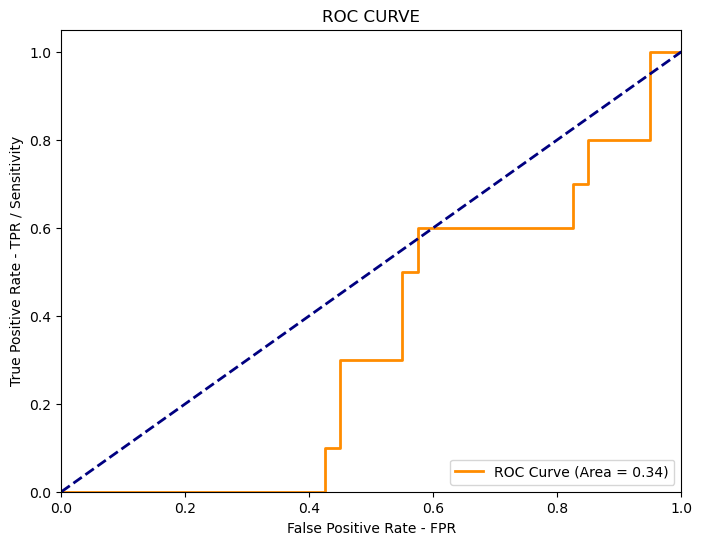

In [40]:
best_thresh = find_best_threshold(y_eval, final_weighted_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")
y_preds = (np.array(final_weighted_probs) >= best_thresh).astype(int)
metrics_dict = calculate_metrics(y_eval, y_preds, final_weighted_probs)

Apnea detected from segment 2 to 34, total duration: 935 seconds
Apnea detected from segment 36 to 49, total duration: 405 seconds

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.07      0.14        40
       Apnea       0.21      1.00      0.35        10

    accuracy                           0.26        50
   macro avg       0.61      0.54      0.25        50
weighted avg       0.84      0.26      0.18        50


--- Confusion Matrix ---
[[ 3 37]
 [ 0 10]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0750
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.2128
Accuracy: 0.2600
F1 Score: 0.3509

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.3475
Precision-Recall AUC Score: 0.1618


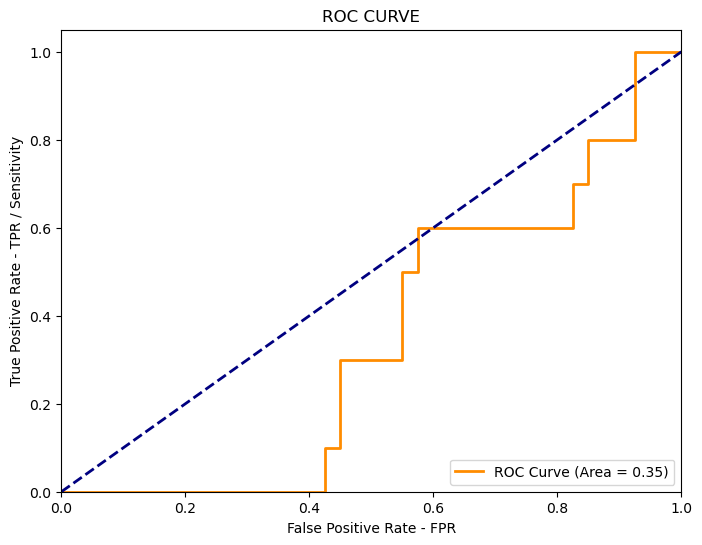

In [41]:
y_pred_apneas, apnea_events, apnea_events_time = check_apnea_criteria(X_eval, y_preds, time_data, resp_int, None)
# Print the detected apnea events
for start, end, duration in apnea_events:
    print(f"Apnea detected from segment {start} to {end}, total duration: {duration} seconds")

#apply the mask of the new apneas refined with the apnea criteria also to the probabilities 
y_pred_apneas_np = np.array(y_pred_apneas)
y_prob_np = np.array(final_weighted_probs)

mask = (y_pred_apneas_np == 0)
y_probs_check = y_prob_np
y_probs_check[mask] = 0

metrics_dict = calculate_metrics(y_eval, y_pred_apneas, y_probs_check)


In [42]:
print('N. apnee detected', len(apnea_events_time))

apnee_intervals = [event[:2] for event in apnea_events_time]
intersecting, unique_list1, unique_list2 = compare_intervals(merged_intervals, apnee_intervals)

print("N. Intervalli Intersecati/apnee trovate:", len(intersecting))
print("N. apnee non trovate:", len(unique_list1))
print("N. apnee trovate in più:", len(unique_list2))

N. apnee detected 2
N. Intervalli Intersecati/apnee trovate: 2
N. apnee non trovate: 4
N. apnee trovate in più: 0
